In [60]:
print('RAM')


RAM


In [61]:
! pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

In [63]:
import pandas as pd

df = pd.read_csv("/Users/tushar/Documents/deve/predictive-maintenance/data/raw/ai4i2020.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())


   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [64]:
print(f"Total Null Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Total Null Values: 0
Duplicate Rows: 0


Check for missing values and duplicates:

In [65]:
df["Machine failure"].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

Remove unnecessary columns


In [66]:
df = df.drop(
    columns=["UDI", "Product ID"]
)
df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [67]:
failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]
df = df.drop(columns=failure_columns)
df.columns


Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

Rename columns

In [68]:
df = df.rename(columns={
    "Type": "machine_type",
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "machine_failure"
})

df.columns



Index(['machine_type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure'],
      dtype='str')

In [69]:
df.dtypes


machine_type               str
air_temperature        float64
process_temperature    float64
rotational_speed         int64
torque                 float64
tool_wear                int64
machine_failure          int64
dtype: object

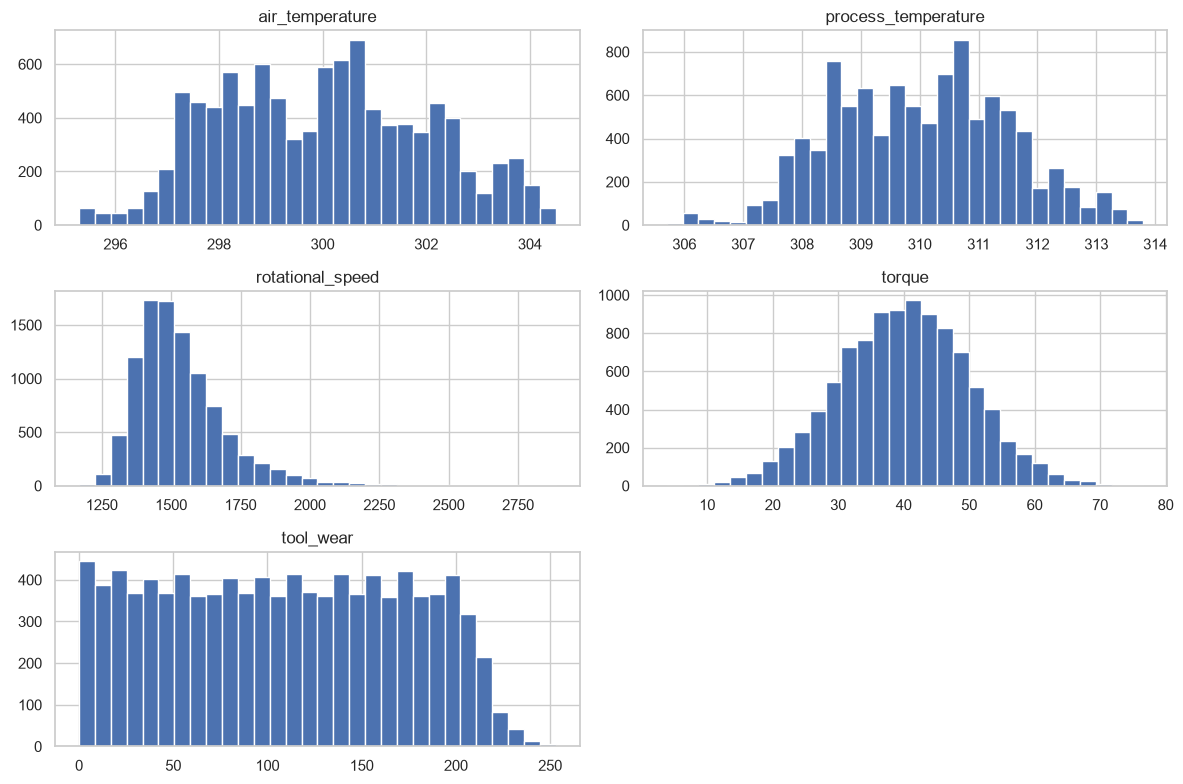

In [70]:
df.describe().T


numeric_columns = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear"
]

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()


Feature engineering

In [71]:
df["temperature_difference"] = (
    df["process_temperature"]
    - df["air_temperature"]
)


In [72]:
df[
    [
        "air_temperature",
        "process_temperature",
        "temperature_difference"
    ]
].head()


,air_temperature,process_temperature,temperature_difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


Mechanical power proxy
Torque and rotational speed are related to mechanical power.

In [73]:
df["power_proxy"] = (
    df["torque"] * df["rotational_speed"]
)


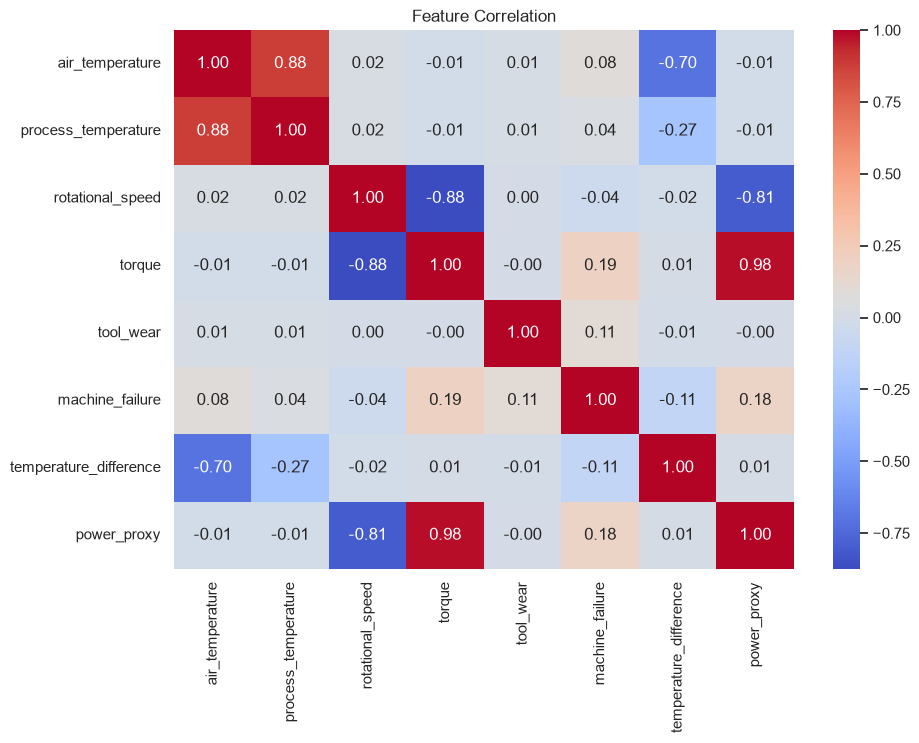

In [74]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.show()


Separate X and y

In [75]:
X = df.drop(
    columns=["machine_failure"]
)


In [76]:
y = df["machine_failure"]


In [77]:
X.shape


(10000, 8)

In [78]:
y.shape


(10000,)

In [79]:
X.head()


,machine_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,power_proxy
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0


In [80]:
y.head()


0    0
1    0
2    0
3    0
4    0
Name: machine_failure, dtype: int64

Conceptually:

X
│
├── machine_type
├── air_temperature
├── process_temperature
├── rotational_speed
├── torque
├── tool_wear
├── temperature_difference
└── power_proxy

y
│
└── machine_failure


Train/test split

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [83]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (8000, 8)
Testing: (2000, 8)


Check target distribution after splitting

In [84]:
print("Training target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))


Training target:
machine_failure
0    0.97
1    0.03
Name: proportion, dtype: float64

Test target:
machine_failure
0    0.97
1    0.03
Name: proportion, dtype: float64


In [85]:
import os

os.makedirs("../../data/processed", exist_ok=True)

df.to_csv(
    "../../data/processed/ai4i_cleaned.csv",
    index=False
)


Target Variable Distribution & Imbalance Check
The primary label is Machine failure. We evaluate both the raw counts and the proportion of failures to quantify class imbalance.

In [82]:
failure_counts = df["Machine failure"].value_counts()
failure_percentages = df["Machine failure"].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    "Count": failure_counts,
    "Percentage (%)": failure_percentages
})
print(summary_target)

# Visualize target imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=summary_target.index, y="Count", data=summary_target, palette="viridis", ax=ax)
ax.set_title("Target Distribution: Machine Failure", fontsize=14, pad=12)
ax.set_xticklabels(["No Failure (0)", "Failure (1)"])
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.show()

KeyError: 'Machine failure'

Analyze Specific Failure Modes
The dataset includes 5 specific failure modes:

TWF (Tool Wear Failure)

HDF (Heat Dissipation Failure)

PWF (Power Failure)

OSF (Overstrain Failure)

RNF (Random Failure)

Evaluate how these correlate with the overarching Machine failure column.

In [ ]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("Specific Failure Mode Counts:")
print(df[failure_modes].sum())

# Check for instances where Machine failure is 1, but no specific mode is flagged
mode_sum = df[failure_modes].sum(axis=1)
unlabeled_failures = df[(df["Machine failure"] == 1) & (mode_sum == 0)]
print(f"\nFailures with no specific mode flagged: {len(unlabeled_failures)}")

# Check for instances where a mode is flagged, but Machine failure is 0
inconsistent_failures = df[(df["Machine failure"] == 0) & (mode_sum > 0)]
print(f"Mode flagged but Machine failure == 0: {len(inconsistent_failures)}")

Specific Failure Mode Counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Failures with no specific mode flagged: 9
Mode flagged but Machine failure == 0: 18


Step 5: Categorical Analysis (Type)
The Type column denotes the product quality variant: L (Low - 50%), M (Medium - 30%), and H (High - 20%).

/var/folders/jf/g1n1jyl12pjgkjyy1bf1hyjw0000gn/T/ipykernel_14996/2111404703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Type", order=["L", "M", "H"], palette="Blues_r", ax=axes[0])
/var/folders/jf/g1n1jyl12pjgkjyy1bf1hyjw0000gn/T/ipykernel_14996/2111404703.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_failure_rate, x="Type", y="Machine failure", order=["L", "M", "H"], palette="Reds_r", ax=axes[1])


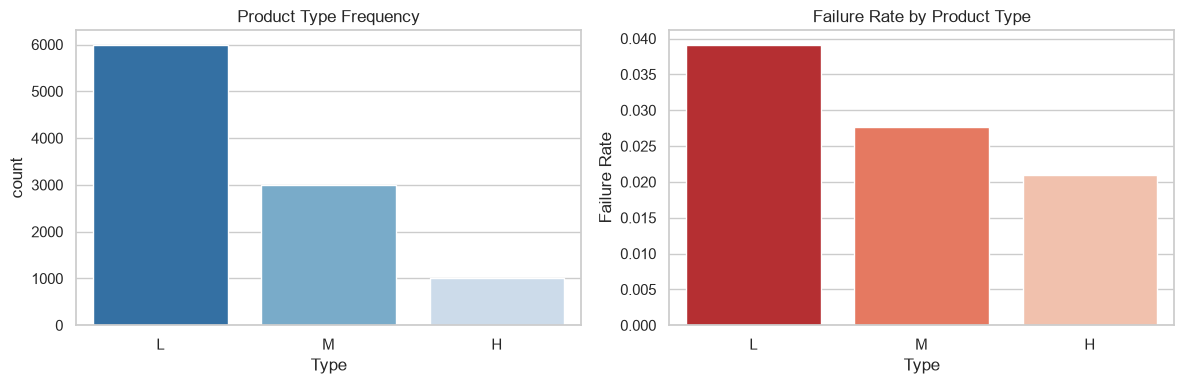

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Frequency of product types
sns.countplot(data=df, x="Type", order=["L", "M", "H"], palette="Blues_r", ax=axes[0])
axes[0].set_title("Product Type Frequency")

# Failure rate per product type
type_failure_rate = df.groupby("Type")["Machine failure"].mean().reset_index()
sns.barplot(data=type_failure_rate, x="Type", y="Machine failure", order=["L", "M", "H"], palette="Reds_r", ax=axes[1])
axes[1].set_title("Failure Rate by Product Type")
axes[1].set_ylabel("Failure Rate")

plt.tight_layout()
plt.show()

Numerical Features Distribution & Outlier Detection
Analyze the continuous sensor attributes:

Air temperature [K]

Process temperature [K]

Rotational speed [rpm]

Torque [Nm]

Tool wear [min]

In [ ]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
Air temperature [K],300.00,2.00,295.3,298.3,300.1,301.5,304.5
Process temperature [K],310.01,1.48,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],39.99,9.97,3.8,33.2,40.1,46.8,76.6
Tool wear [min],107.95,63.65,0.0,53.0,108.0,162.0,253.0


/var/folders/jf/g1n1jyl12pjgkjyy1bf1hyjw0000gn/T/ipykernel_14996/3499420627.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=axes[idx, 1], palette="coolwarm")
/var/folders/jf/g1n1jyl12pjgkjyy1bf1hyjw0000gn/T/ipykernel_14996/3499420627.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[idx, 1].set_xticklabels(["No Failure (0)", "Failure (1)"])
/var/folders/jf/g1n1jyl12pjgkjyy1bf1hyjw0000gn/T/ipykernel_14996/3499420627.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=axes[idx, 1], p

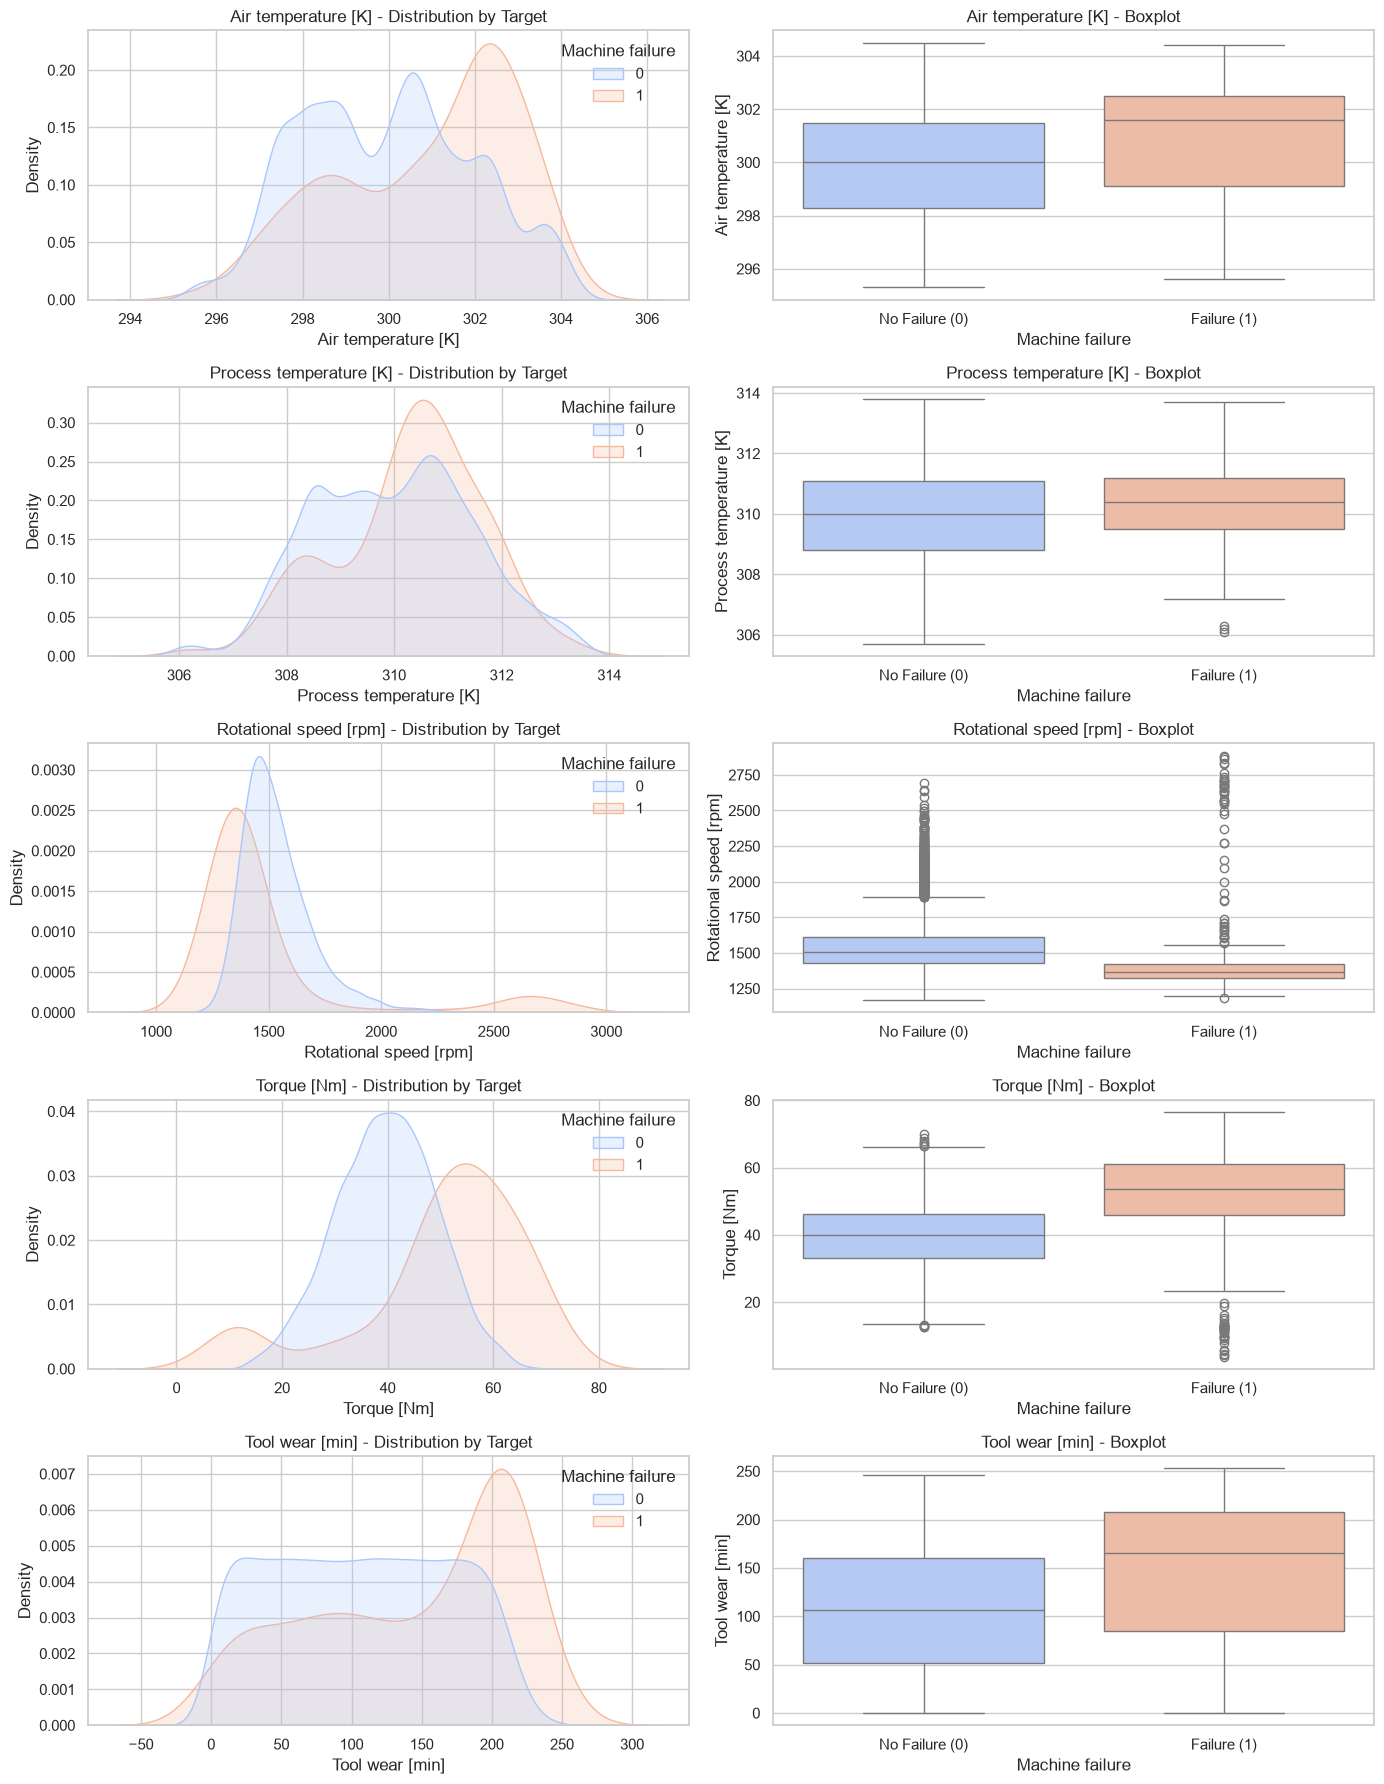

In [ ]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 18))

for idx, col in enumerate(numeric_cols):
    # Density plot
    sns.kdeplot(data=df, x=col, hue="Machine failure", common_norm=False, fill=True, ax=axes[idx, 0], palette="coolwarm")
    axes[idx, 0].set_title(f"{col} - Distribution by Target")
    
    # Box plot
    sns.boxplot(data=df, x="Machine failure", y=col, ax=axes[idx, 1], palette="coolwarm")
    axes[idx, 1].set_xticklabels(["No Failure (0)", "Failure (1)"])
    axes[idx, 1].set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()

Correlation and Interaction Analysis
Compute linear relationships between sensor variables and failure flags.

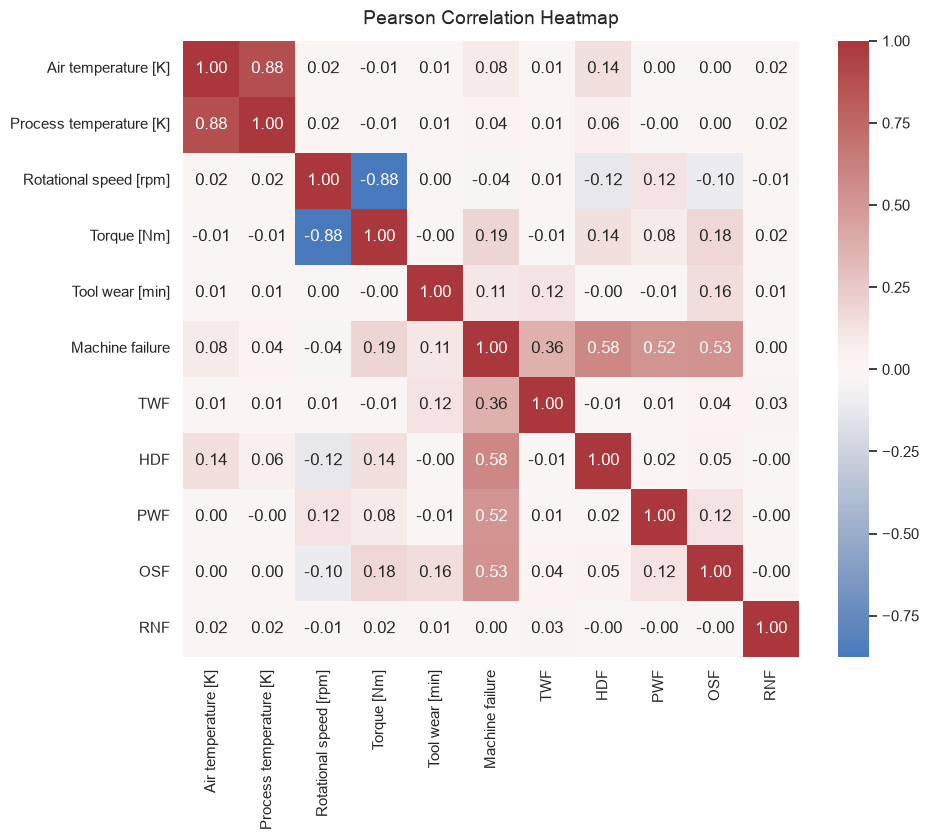

In [ ]:
analysis_features = numeric_cols + ["Machine failure"] + failure_modes

plt.figure(figsize=(10, 8))
corr_matrix = df[analysis_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Pearson Correlation Heatmap", fontsize=14, pad=12)
plt.show()

Domain Insight: The curve of Torque [Nm] versus Rotational speed [rpm] reflects an inverse hyperbolic curve ($P = \tau \cdot \omega$). Failures appear at the power curve extremes (overstrain at high torque, power failure at excessive/insufficient power).


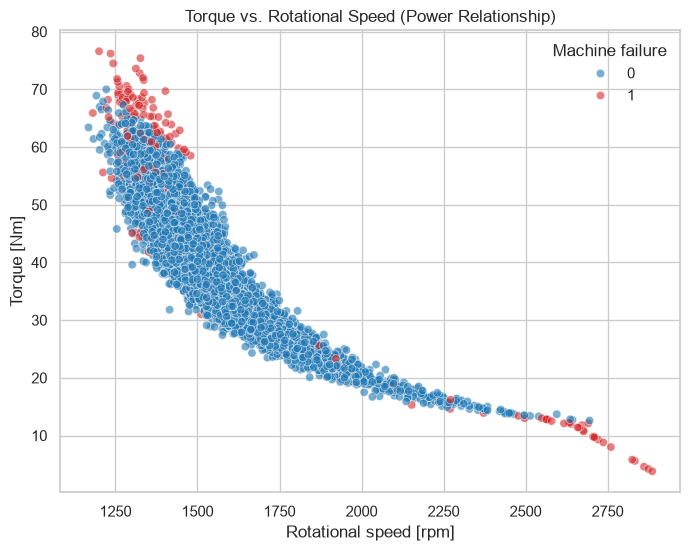

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.6,
    palette={0: "tab:blue", 1: "tab:red"}
)
plt.title("Torque vs. Rotational Speed (Power Relationship)")
plt.show()

EDA Conclusions & Next Pipeline StepsRun a final summary markdown cell to document modeling implications:Identifiers to Drop: UDI and Product ID carry no generalized signal and must be discarded.Leakage Targets to Drop: TWF, HDF, PWF, OSF, and RNF are downstream indicators of specific failure modes. Using them as inputs to predict general Machine failure causes 100% data leakage.Engineered Features to Add:$\Delta T = \text{Process Temperature} - \text{Air Temperature}$ (critical for heat dissipation failures).$P \propto \text{Torque} \times \text{Rotational Speed}$ (critical for power and overstrain failures).Resampling / Loss Strategy: The 96.6% to 3.4% imbalance requires either scale_pos_weight in tree models, balanced class weighting, or probability calibration with custom thresholding.

In [ ]:
df["Machine failure"].value_counts(normalize=True)


Machine failure
0    0.97
1    0.03
Name: proportion, dtype: float64